# Imports

In [2]:
import os
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [3]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn

from src.simulacao import simular_mercado_e_plotar

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 17.42 MiB/s, done.
Resolving deltas: 100% (100/100), done.
/content/Mercado-Artificial-Fiis


In [4]:
from src.simulacao import simular_mercado_e_plotar, plotar_resultado, SIM_PARAMS

In [5]:
from src.agentes import Agente, gerar_literacia_financeira
from src.ativos import FII, Imovel
from src.mercado import Mercado, BancoCentral, Midia

In [6]:
parametros_sistema = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/parametros_sistema_calibrados.csv').to_numpy()[0]

parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

In [7]:
import copy

params = copy.deepcopy(SIM_PARAMS)
NUM_DIAS    = 60

# # Rodar sem plotar
# resultado = simular_mercado_e_plotar(
#     parametros_sistema=parametros_sistema,
#     num_dias=NUM_DIAS,
#     sim_params=params,
#     imprimir=False,
# )

# Função para o Experimento

In [8]:
def simular_experimento_choque_por_literacia(
    parametros_sistema,
    num_dias=60,
    sim_params=None,
    lf_targets=[0.3, 0.5, 0.8],
    agentes_por_grupo=5,
):
    """
    Experimento: como grupos com diferentes níveis de literacia financeira
    reagem a um choque? Preços e comportamento dos agentes da mesma simulação.

    Parâmetros
    ----------
    parametros_sistema : list
        Vetor calibrado [a0, b0, c0, beta, peso_preco_esperado].
    num_dias : int
        Número de dias da simulação.
    sim_params : dict, opcional
        Se None, usa SIM_PARAMS global.
    lf_targets : list
        Níveis de LF alvo para os grupos.
    agentes_por_grupo : int
        Número de agentes por grupo.
    """

    # ── Configuração ──────────────────────────────────────────
    params = copy.deepcopy(sim_params if sim_params is not None else SIM_PARAMS)
    params["num_dias"] = num_dias
    params["parametros_sentimento"].update({
        "a0":                  parametros_sistema[0],
        "b0":                  parametros_sistema[1],
        "c0":                  parametros_sistema[2],
        "beta":                parametros_sistema[3],
        "peso_preco_esperado": parametros_sistema[4],
    })
    params["parametros_sentimento"]["prob_choque_diario"] = params.get("prob_choque_diario", 0.025)

    # ── FII e Imóveis ─────────────────────────────────────────
    fii = FII(
        num_cotas=params["fii"]["num_cotas"],
        caixa=params["fii"]["caixa_inicial"],
        params=params["fii"],
    )
    for ip in params["imoveis"]:
        fii.adicionar_imovel(Imovel(
            valor=ip["valor"], vacancia=ip["vacancia"],
            custo_manutencao=ip["custo_manutencao"],
            params=ip.get("params", None),
        ))
    historia       = fii.inicializar_historico(memoria=params["fii"]["memoria"])
    fii.preco_cota = fii.historico_precos[-1]

    # ── Agentes PF ────────────────────────────────────────────
    agentes_pf = []
    for i in range(params["num_agentes_pf"]):
        cotas = (params["agente_pf"]["cotas_iniciais_primeiro"]
                 if i == 0 else params["agente_pf"]["cotas_iniciais_outros"])
        agentes_pf.append(Agente(
            id=i,
            literacia_financeira=gerar_literacia_financeira(minimo=0.2, maximo=0.7),
            caixa=params["agente_pf"]["caixa_inicial"],
            cotas=cotas,
            expectativa_inflacao=params["agente_pf"]["expectativa_inflacao"],
            expectativa_premio=params["agente_pf"]["expectativa_premio"],
            historico_precos=historia,
            params=params["agente_pf"].get("params", None),
        ))

    # ── Agentes PJ ────────────────────────────────────────────
    agentes_pj = []
    for i in range(params["num_agentes_pj"]):
        cotas = (params["agente_pj"]["cotas_iniciais_primeiro"]
                 if i == 0 else params["agente_pj"]["cotas_iniciais_outros"])
        agentes_pj.append(Agente(
            id=i + params["num_agentes_pf"],
            literacia_financeira=gerar_literacia_financeira(minimo=0.7, maximo=1.0),
            caixa=params["agente_pj"]["caixa_inicial"],
            cotas=cotas,
            expectativa_inflacao=params["agente_pj"]["expectativa_inflacao"],
            expectativa_premio=params["agente_pj"]["expectativa_premio"],
            historico_precos=historia,
            params=params["agente_pj"].get("params", None),
        ))

    # ── Combinar e definir vizinhos ───────────────────────────
    agentes = agentes_pf + agentes_pj
    for agente in agentes_pf:
        agente.definir_vizinhos(agentes,
                                num_vizinhos=params["agente_pf"]["num_vizinhos"],
                                epsilon_lf=params["agente_pf"].get("epsilon_lf", 1.0))
    for agente in agentes_pj:
        agente.definir_vizinhos(agentes_pj,
                                num_vizinhos=int(params["agente_pj"]["num_vizinhos"]),
                                epsilon_lf=params["agente_pj"].get("epsilon_lf", 1.0))

    # ── Banco Central, Mídia e Mercado ────────────────────────
    bc = BancoCentral(params["banco_central"])
    midia = Midia(dias=num_dias, valor_inicial=params["midia"]["valor_inicial"],
                  sigma=params["midia"]["sigma"],
                  valores_fixos=params["midia"]["valores_fixos"])
    mercado = Mercado(agentes=agentes, imoveis=fii.imoveis, fii=fii,
                      banco_central=bc, midia=midia, params=params["mercado"])

    parametros_sentimento = params["parametros_sentimento"]
    choques               = params.get("choques", [])
    dia_choque            = choques[0]["dia"] if choques else None

    # ── Grupos por literacia ──────────────────────────────────
    agentes_ordenados = sorted(mercado.agentes, key=lambda a: a.LF)
    grupos = {}
    for lf_target in lf_targets:
        agentes_proximos = sorted(agentes_ordenados,
                                  key=lambda a: abs(a.LF - lf_target))[:agentes_por_grupo]
        grupos[f"LF_{lf_target:.2f}"] = agentes_proximos
        print(f"🎯 Grupo LF ≈ {lf_target:.2f}: {[round(a.LF, 3) for a in agentes_proximos]}")

    # ── Estruturas de coleta ──────────────────────────────────
    sentimentos = {nome: [] for nome in grupos}
    prob        = {nome: [] for nome in grupos}
    inflacao    = {nome: [] for nome in grupos}
    premio      = {nome: [] for nome in grupos}
    precos_sim  = []

    # ── Loop único ────────────────────────────────────────────
    for dia in range(1, num_dias + 1):

        for choque in choques:
            if choque.get("dia") != dia:
                continue
            categoria = choque.get("categoria", "noticia")
            if categoria == "noticia":
                for ag in mercado.agentes:
                    ag.aplicar_choque(
                        tipo_choque=choque.get("tipo", "negativo"),
                        intensidade=choque.get("intensidade", 0.5),
                        duracao=choque.get("duracao", 2),
                        delta=choque.get("delta", 0.8),
                    )
                intensidade = choque.get("intensidade", 0.5)
                mercado._choque_news = (-(1 + 2 * intensidade)
                                        if choque.get("tipo") == "negativo"
                                        else +(1 + 2 * intensidade))
            elif categoria == "macro":
                if "inflacao" in choque:
                    mercado.banco_central.expectativa_inflacao = choque["inflacao"]
                if "premio" in choque:
                    mercado.banco_central.premio_risco = choque["premio"]
            elif categoria == "micro":
                for im in mercado.fii.imoveis:
                    if "vac" in choque:
                        im.vacancia *= (1 + choque["vac"] / 100)
                    if "custo" in choque:
                        im.custo_manutencao *= (1 + choque["custo"] / 100)

        mercado.executar_dia(parametros_sentimento)

        # Coleta preços e comportamento na mesma iteração
        precos_sim.append(mercado.fii.preco_cota)
        for nome, agentes_grupo in grupos.items():
            sentimentos[nome].append(np.mean([ag.sentimento           for ag in agentes_grupo]))
            prob[nome].append(       np.mean([ag.prob_negociar        for ag in agentes_grupo]))
            inflacao[nome].append(   np.mean([ag.expectativa_inflacao for ag in agentes_grupo]))
            premio[nome].append(     np.mean([ag.expectativa_premio   for ag in agentes_grupo]))

    precos_sim = np.array(precos_sim)
    dias_sim   = np.arange(1, num_dias + 1)

# ── Plot ──────────────────────────────────────────────────
# ── Plot ──────────────────────────────────────────────────
    CORES_CHOQUE = {
        "noticia_positivo": "#2ca02c",
        "noticia_negativo": "#d62728",
        "macro":            "#ff7f0e",
        "micro":            "#9467bd",
    }

    def marcar_choques(ax):
        for choque in choques:
            dia = choque["dia"]
            cat = choque["categoria"]
            if cat == "noticia":
                tipo = choque.get("tipo", "negativo")
                cor  = CORES_CHOQUE[f"noticia_{tipo}"]
                lbl  = f"Notícia {tipo} (dia {dia})"
            elif cat == "macro":
                cor = CORES_CHOQUE["macro"]
                lbl = f"Macro (dia {dia})"
            else:
                cor = CORES_CHOQUE["micro"]
                lbl = f"Micro (dia {dia})"
            ax.axvline(dia, color=cor, ls="--", lw=1.5, label=lbl)

    fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

    # Painel 1 — Preços
    axes[0].plot(dias_sim, precos_sim, color="#1a1a2e", lw=1.8)
    marcar_choques(axes[0])
    axes[0].set_title("Série de Preços", fontsize=11, fontweight="bold", loc="left")
    axes[0].set_ylabel("Preço (R$)")
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(True, alpha=0.3)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # Painéis 2-5 — Comportamento por grupo
    for ax, dados, titulo, ylabel in [
        (axes[1], sentimentos, "Sentimento",              "Sentimento"),
        (axes[2], prob,        "Prob. de Negociar",       "Prob. de Negociar"),
        (axes[3], inflacao,    "Expectativa de Inflação", "Expectativa de Inflação"),
        (axes[4], premio,      "Expectativa de Prêmio",   "Expectativa de Prêmio"),
    ]:
        marcar_choques(ax)
        for nome, serie in dados.items():
            ax.plot(dias_sim, serie, label=nome)
        ax.set_title(titulo, fontsize=11, fontweight="bold", loc="left")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Dia")
    plt.tight_layout()
    plt.show()

    return {
        "precos_sim":   precos_sim,
        "sentimentos":  sentimentos,
        "prob":         prob,
        "inflacao":     inflacao,
        "premio":       premio,
        "grupos":       grupos,
    }

# Notícia Negativa

🎯 Grupo LF ≈ 0.20: [np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.201), np.float64(0.201)]
🎯 Grupo LF ≈ 0.50: [np.float64(0.501), np.float64(0.501), np.float64(0.497), np.float64(0.497), np.float64(0.503)]
🎯 Grupo LF ≈ 0.80: [np.float64(0.8), np.float64(0.8), np.float64(0.799), np.float64(0.799), np.float64(0.799)]


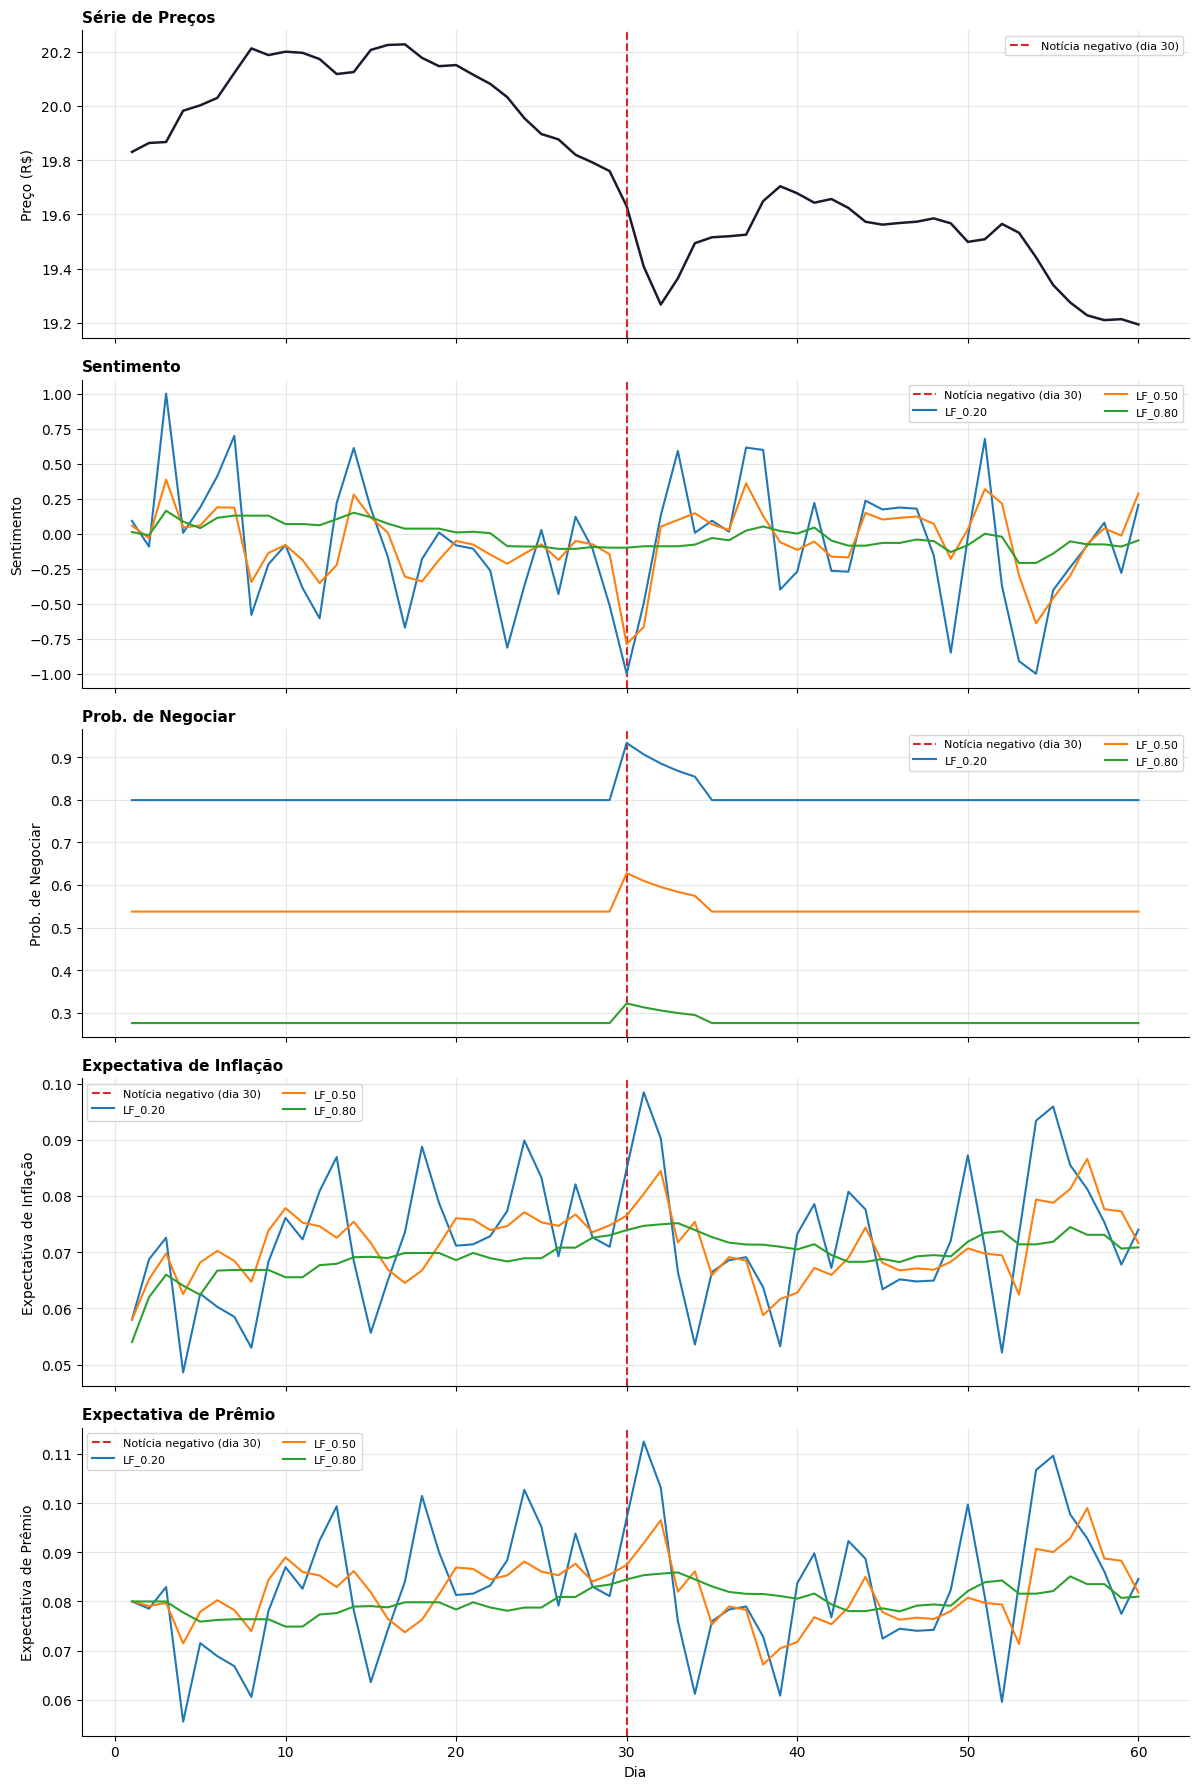

In [16]:
params["choques"] = [
    {
        "categoria":   "noticia",
        "dia":         30,
        "tipo":        "negativo",
        "intensidade": 0.7,
        "duracao":     5,
        "delta":       0.8,
    }
]

resultado = simular_experimento_choque_por_literacia(
    parametros_sistema=parametros_sistema,
    num_dias=60,
    sim_params=params,
    lf_targets=[0.2, 0.5, 0.8],
    agentes_por_grupo=5,
)

# Notícia Positiva

🎯 Grupo LF ≈ 0.30: [np.float64(0.3), np.float64(0.3), np.float64(0.3), np.float64(0.299), np.float64(0.302)]
🎯 Grupo LF ≈ 0.50: [np.float64(0.499), np.float64(0.497), np.float64(0.497), np.float64(0.503), np.float64(0.496)]
🎯 Grupo LF ≈ 0.80: [np.float64(0.801), np.float64(0.802), np.float64(0.803), np.float64(0.797), np.float64(0.803)]
⚡ Choque aleatório negativo no dia 28 (intensidade 0.54)
⚡ Choque aleatório negativo no dia 39 (intensidade 0.33)
⚡ Choque aleatório negativo no dia 42 (intensidade 0.66)


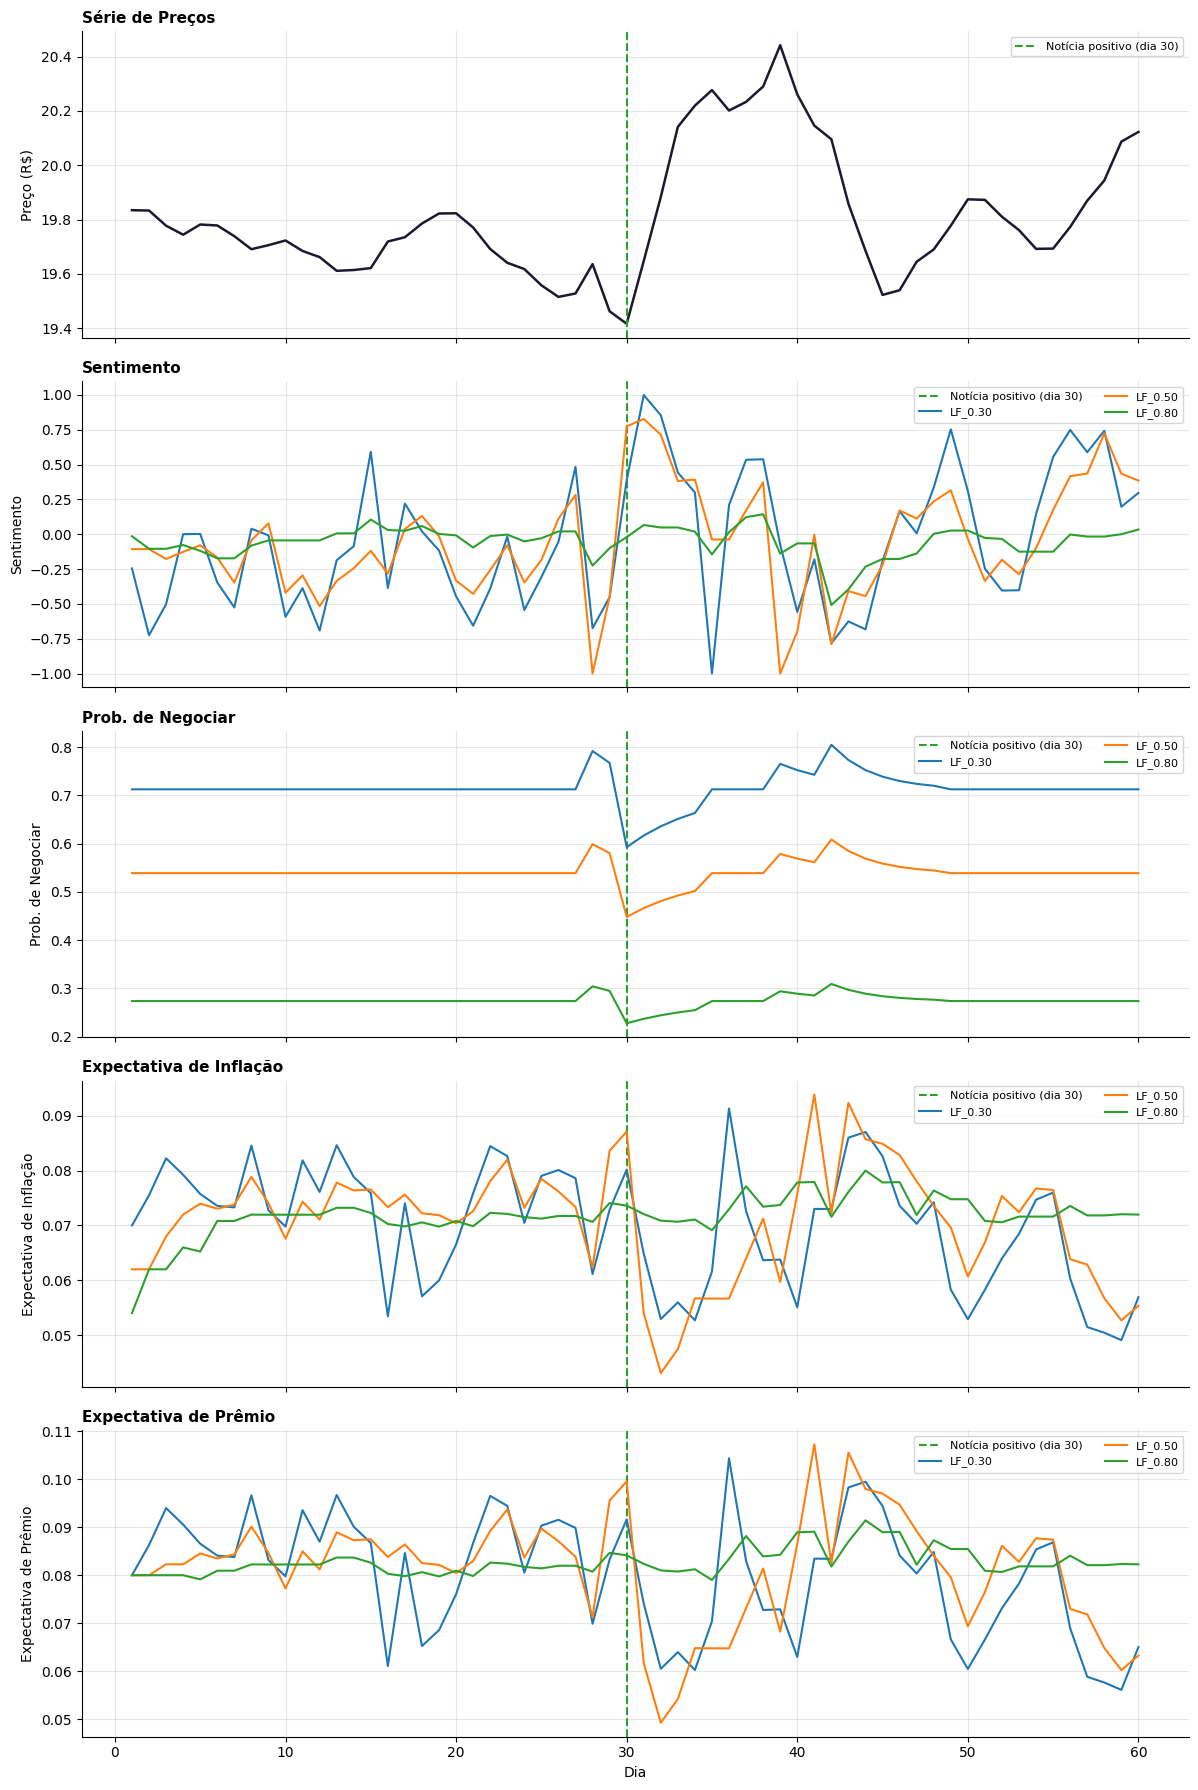

In [15]:
params["choques"] = [
    {
        "categoria":   "noticia",
        "dia":         30,
        "tipo":        "positivo",
        "intensidade": 0.7,
        "duracao":     5,
        "delta":       0.8,
    }
]

resultado = simular_experimento_choque_por_literacia(
    parametros_sistema=parametros_sistema,
    num_dias=60,
    sim_params=params,
    lf_targets=[0.3, 0.5, 0.8],
    agentes_por_grupo=5,
)

# Subida na Inflação e Prêmio

🎯 Grupo LF ≈ 0.30: [np.float64(0.299), np.float64(0.299), np.float64(0.302), np.float64(0.302), np.float64(0.302)]
🎯 Grupo LF ≈ 0.50: [np.float64(0.501), np.float64(0.502), np.float64(0.505), np.float64(0.506), np.float64(0.507)]
🎯 Grupo LF ≈ 0.80: [np.float64(0.801), np.float64(0.801), np.float64(0.802), np.float64(0.802), np.float64(0.803)]


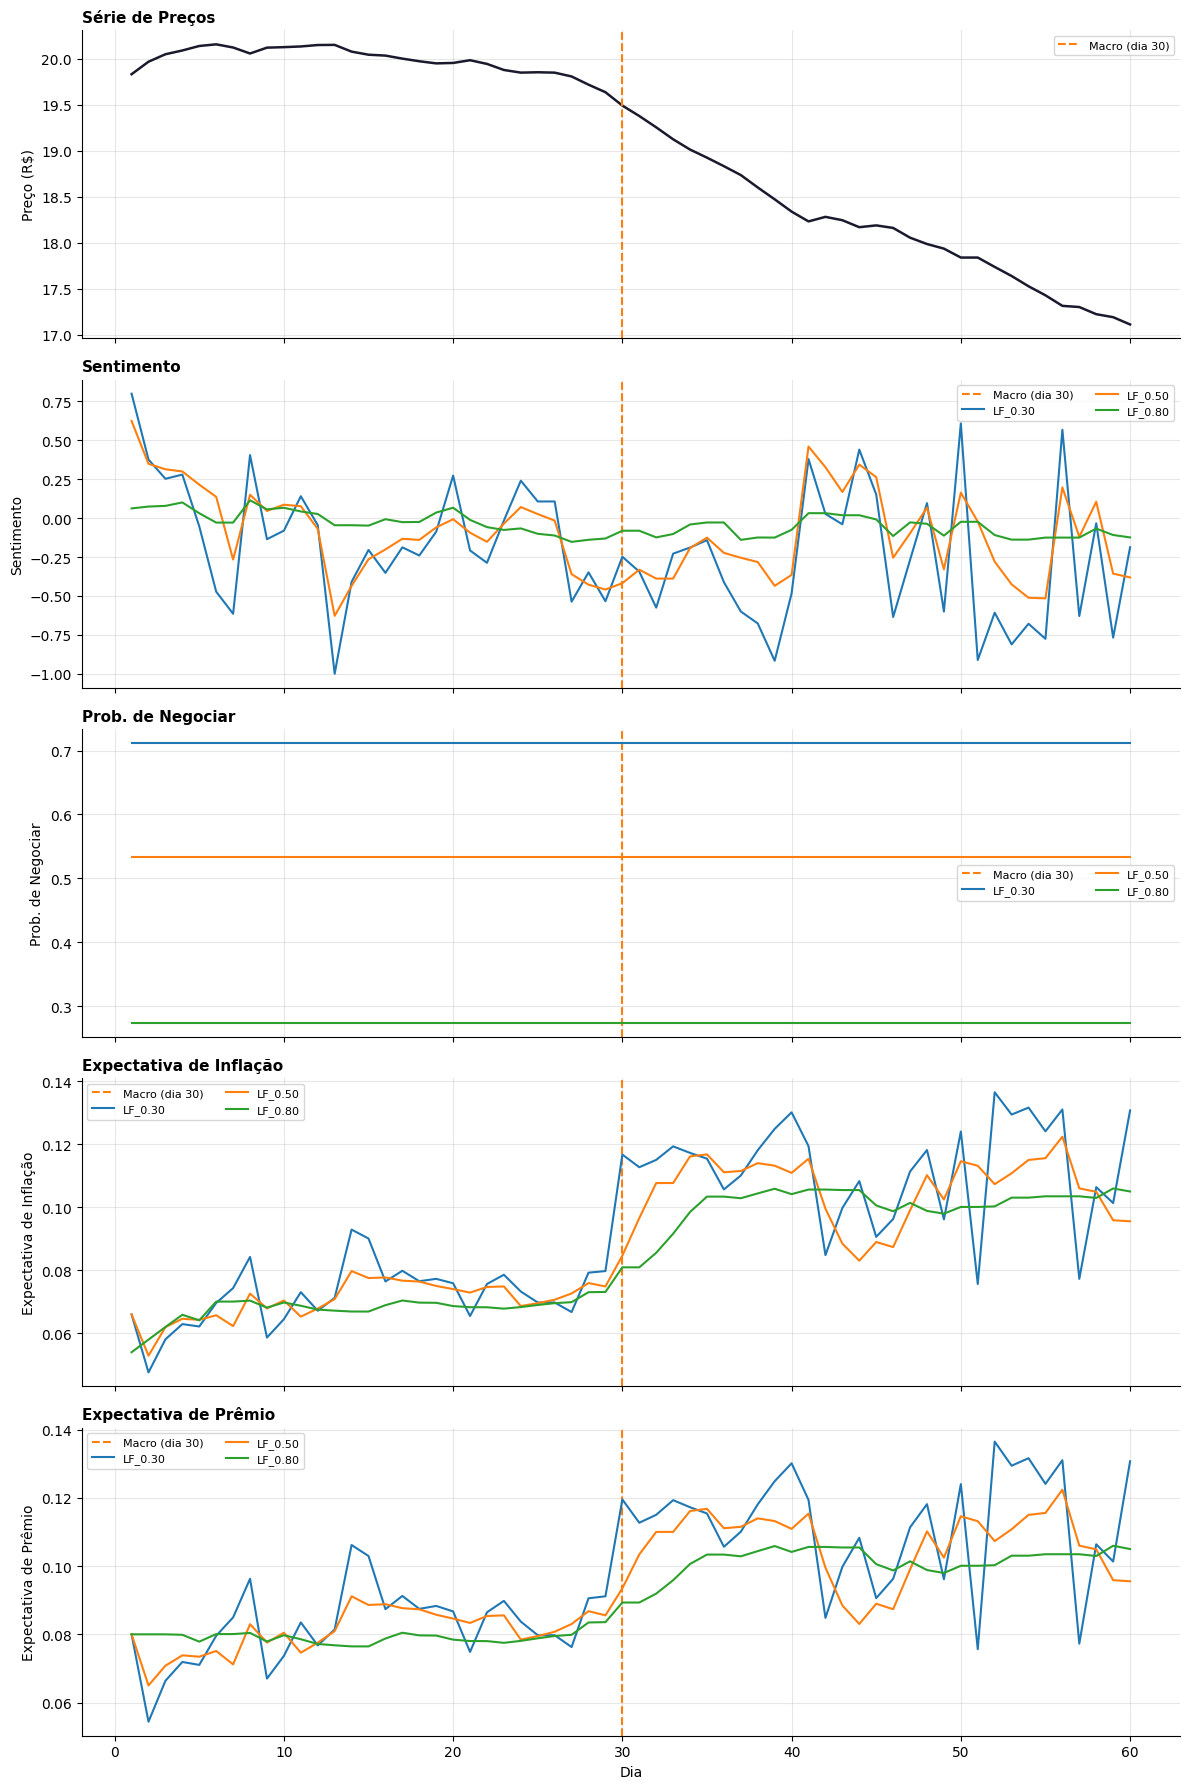

In [11]:
params = copy.deepcopy(SIM_PARAMS)
params["prob_choque_diario"] = 0.0  # sem choques aleatórios
params["choques"] = [
    {
        "categoria": "macro",
        "dia":       30,
        "inflacao":  0.10,   # inflação sobe de 7% para 10%
        "premio":    0.10,   # prêmio de risco sobe de 8% para 10%
    }
]

resultado = simular_experimento_choque_por_literacia(
    parametros_sistema=parametros_sistema,
    num_dias=60,
    sim_params=params,
    lf_targets=[0.3, 0.5, 0.8],
    agentes_por_grupo=5,
)




Caída da Inflação e Prêmio

🎯 Grupo LF ≈ 0.30: [np.float64(0.3), np.float64(0.299), np.float64(0.301), np.float64(0.301), np.float64(0.302)]
🎯 Grupo LF ≈ 0.50: [np.float64(0.5), np.float64(0.502), np.float64(0.498), np.float64(0.495), np.float64(0.506)]
🎯 Grupo LF ≈ 0.80: [np.float64(0.8), np.float64(0.801), np.float64(0.801), np.float64(0.799), np.float64(0.799)]
⚡ Choque aleatório negativo no dia 51 (intensidade 0.67)


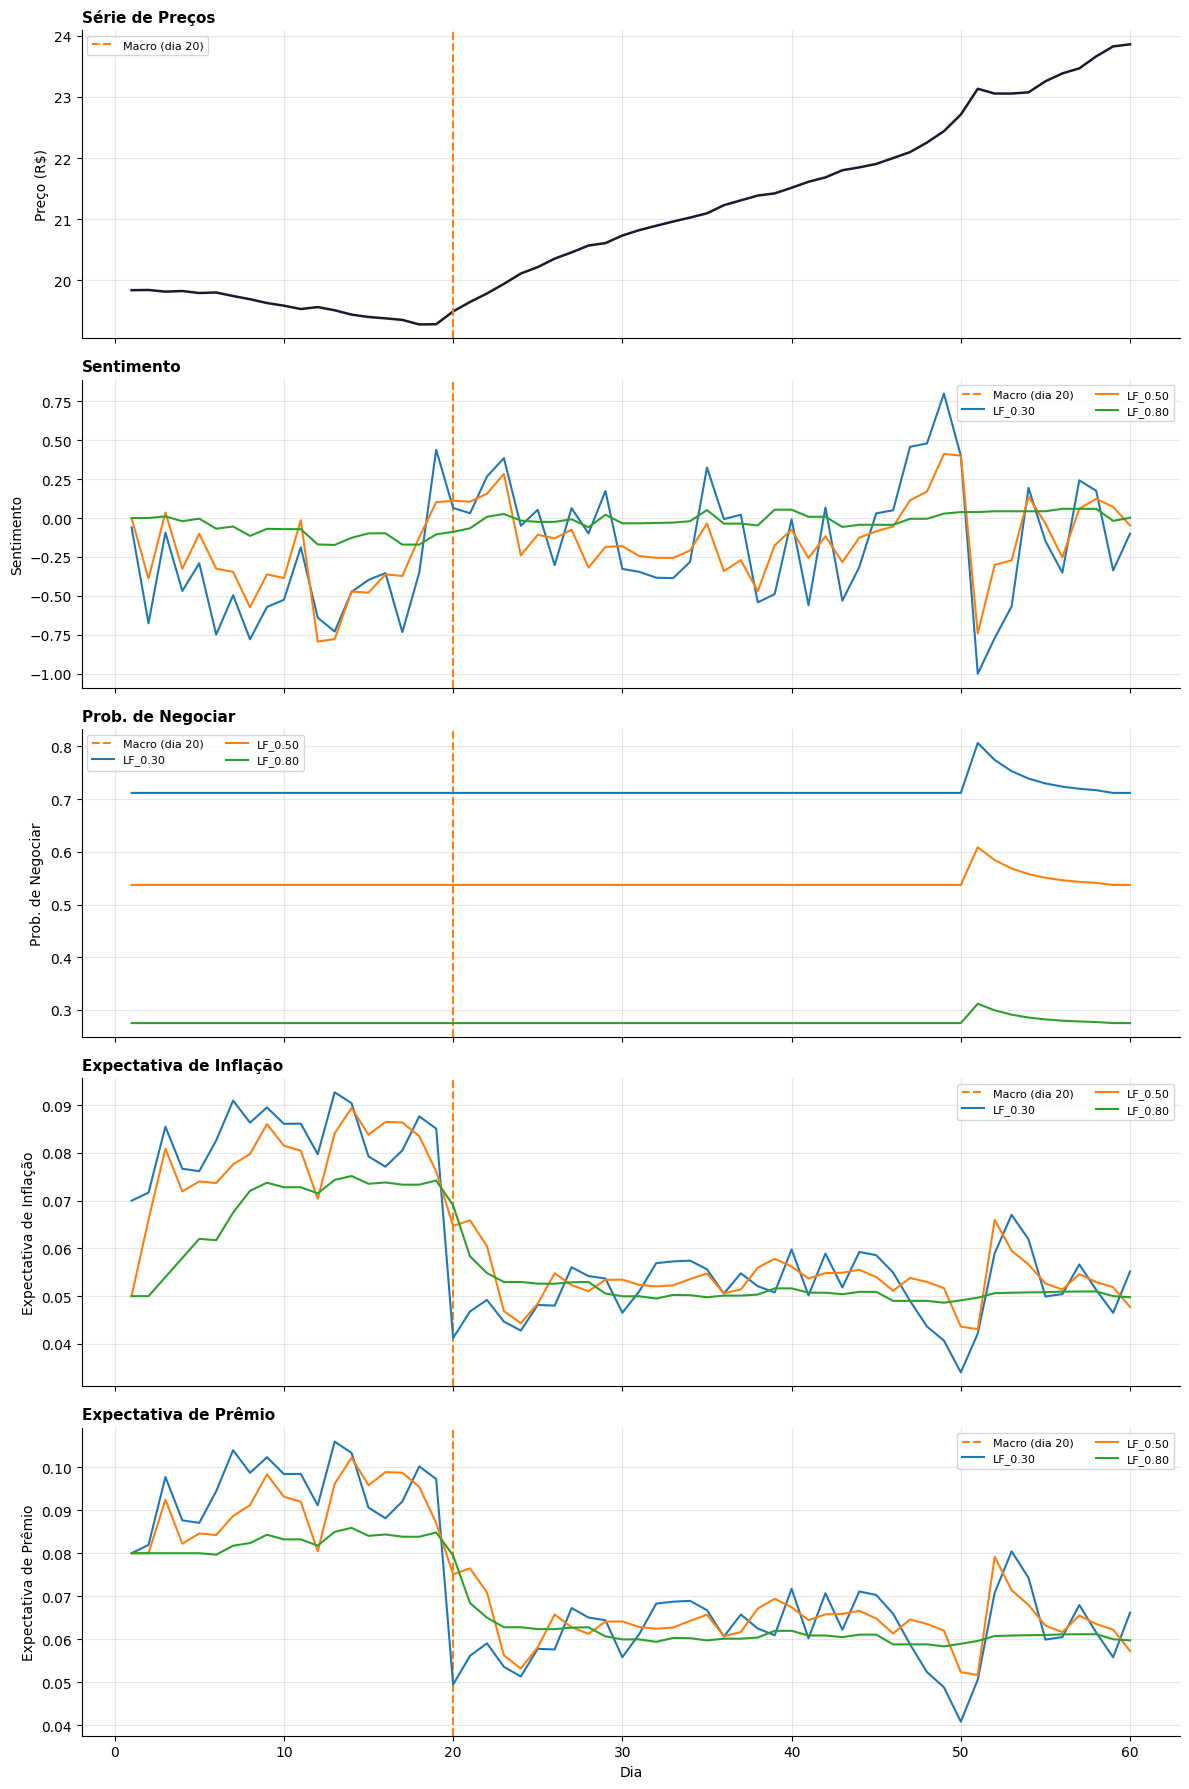

In [12]:
params = copy.deepcopy(SIM_PARAMS)
params["prob_choque_diario"] = 0.025  # sem choques aleatórios
params["choques"] = [
    {
        "categoria": "macro",
        "dia":       20,
        "inflacao":  0.05,   # inflação cai de 7% para 5%
        "premio":    0.06,   # prêmio de risco cai de 8% para 6%
    }
]

resultado = simular_experimento_choque_por_literacia(
    parametros_sistema=parametros_sistema,
    num_dias=60,
    sim_params=params,
    lf_targets=[0.3, 0.5, 0.8],
    agentes_por_grupo=5,
)

# Diminuição da Vacância e Custos

🎯 Grupo LF ≈ 0.30: [np.float64(0.301), np.float64(0.302), np.float64(0.302), np.float64(0.302), np.float64(0.302)]
🎯 Grupo LF ≈ 0.50: [np.float64(0.5), np.float64(0.499), np.float64(0.498), np.float64(0.502), np.float64(0.503)]
🎯 Grupo LF ≈ 0.80: [np.float64(0.799), np.float64(0.802), np.float64(0.802), np.float64(0.802), np.float64(0.798)]
⚡ Choque aleatório positivo no dia 22 (intensidade 0.46)


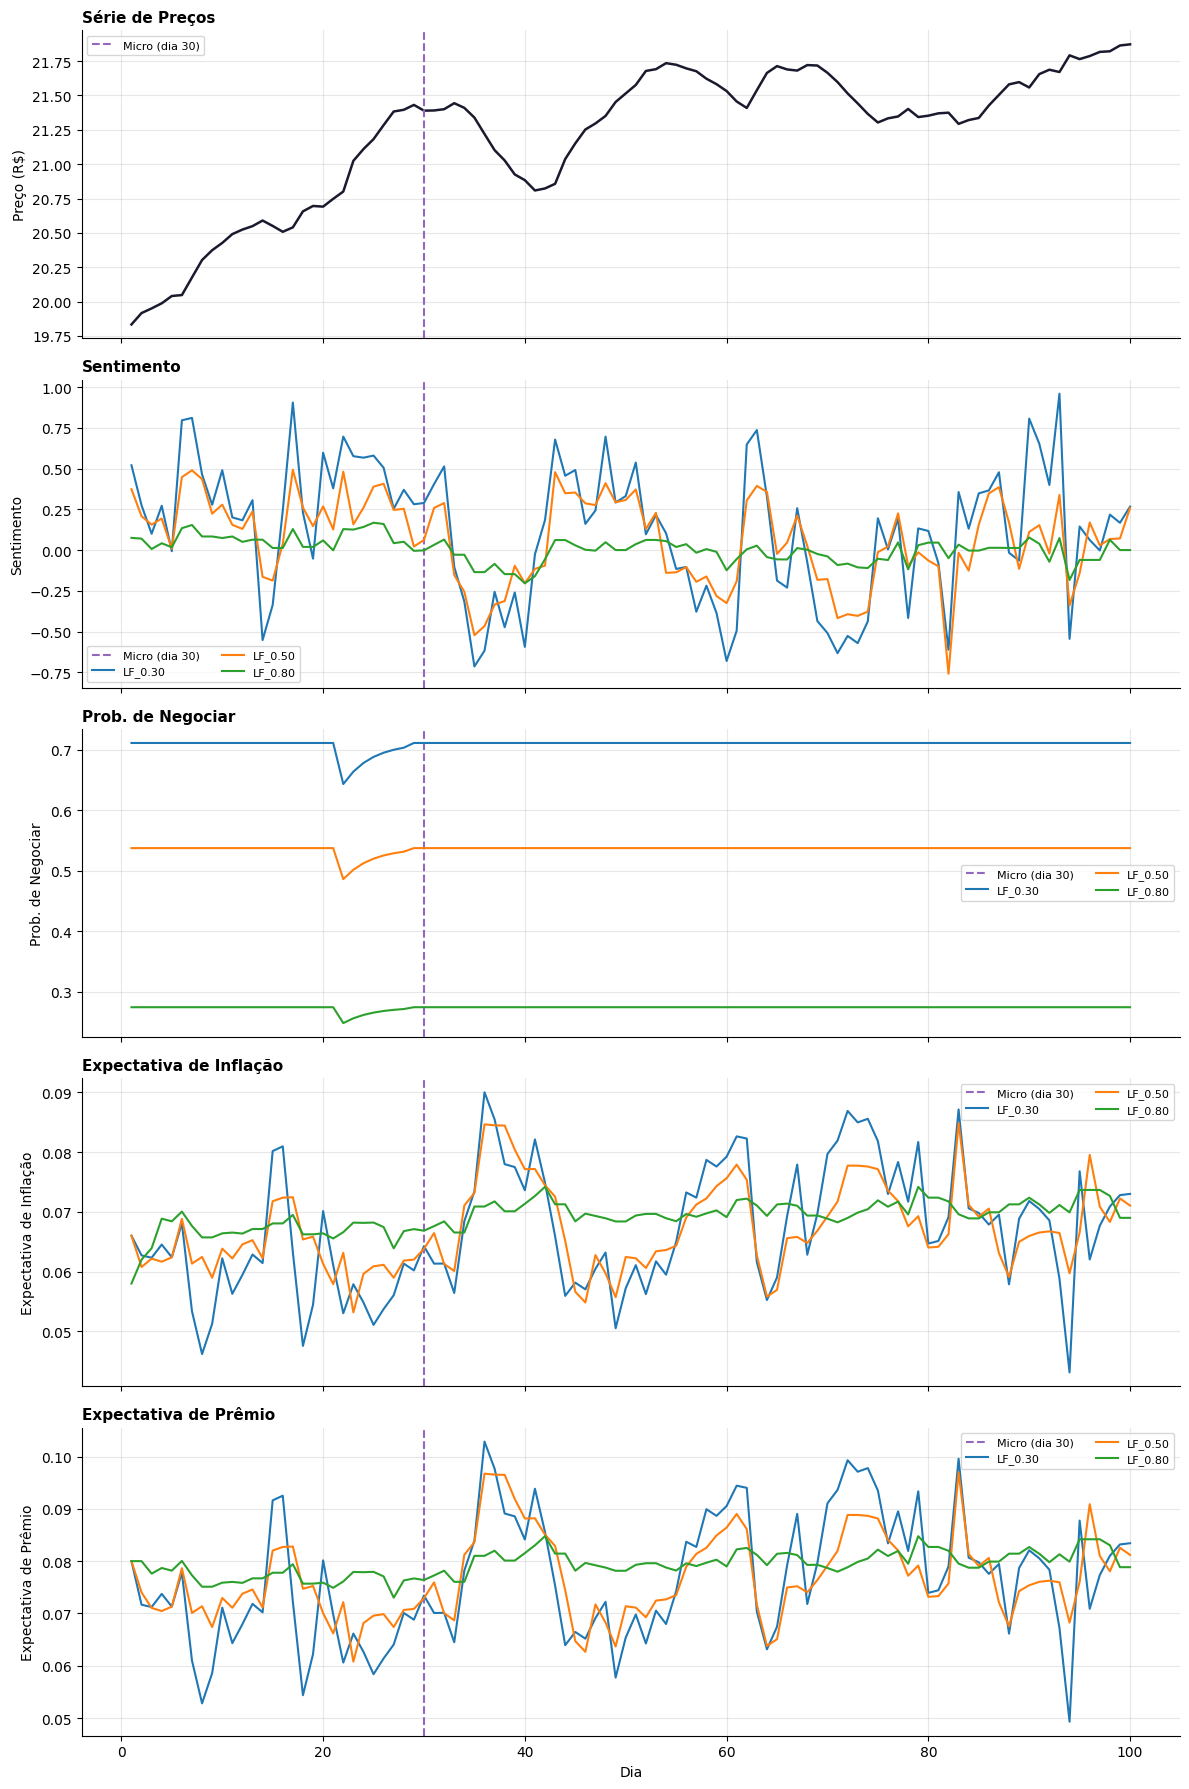

In [13]:
params = copy.deepcopy(SIM_PARAMS)
params["prob_choque_diario"] = 0.025  # sem choques aleatórios
params["choques"] = [
    {
        "categoria": "micro",
        "dia":       30,
        "vac":       -50,   # vacância cai 50%
        "custo":     -30,   # custo de manutenção cai 30%
    }
]

resultado = simular_experimento_choque_por_literacia(
    parametros_sistema=parametros_sistema,
    num_dias=100,
    sim_params=params,
    lf_targets=[0.3, 0.5, 0.8],
    agentes_por_grupo=5,
)

# Aumento da Vacância e Custos

🎯 Grupo LF ≈ 0.20: [np.float64(0.2), np.float64(0.201), np.float64(0.201), np.float64(0.201), np.float64(0.202)]
🎯 Grupo LF ≈ 0.50: [np.float64(0.501), np.float64(0.501), np.float64(0.499), np.float64(0.498), np.float64(0.502)]
🎯 Grupo LF ≈ 0.80: [np.float64(0.799), np.float64(0.803), np.float64(0.803), np.float64(0.804), np.float64(0.796)]
⚡ Choque aleatório negativo no dia 35 (intensidade 0.66)
⚡ Choque aleatório negativo no dia 49 (intensidade 0.31)
⚡ Choque aleatório positivo no dia 54 (intensidade 0.39)
⚡ Choque aleatório negativo no dia 77 (intensidade 0.39)
⚡ Choque aleatório negativo no dia 88 (intensidade 0.45)


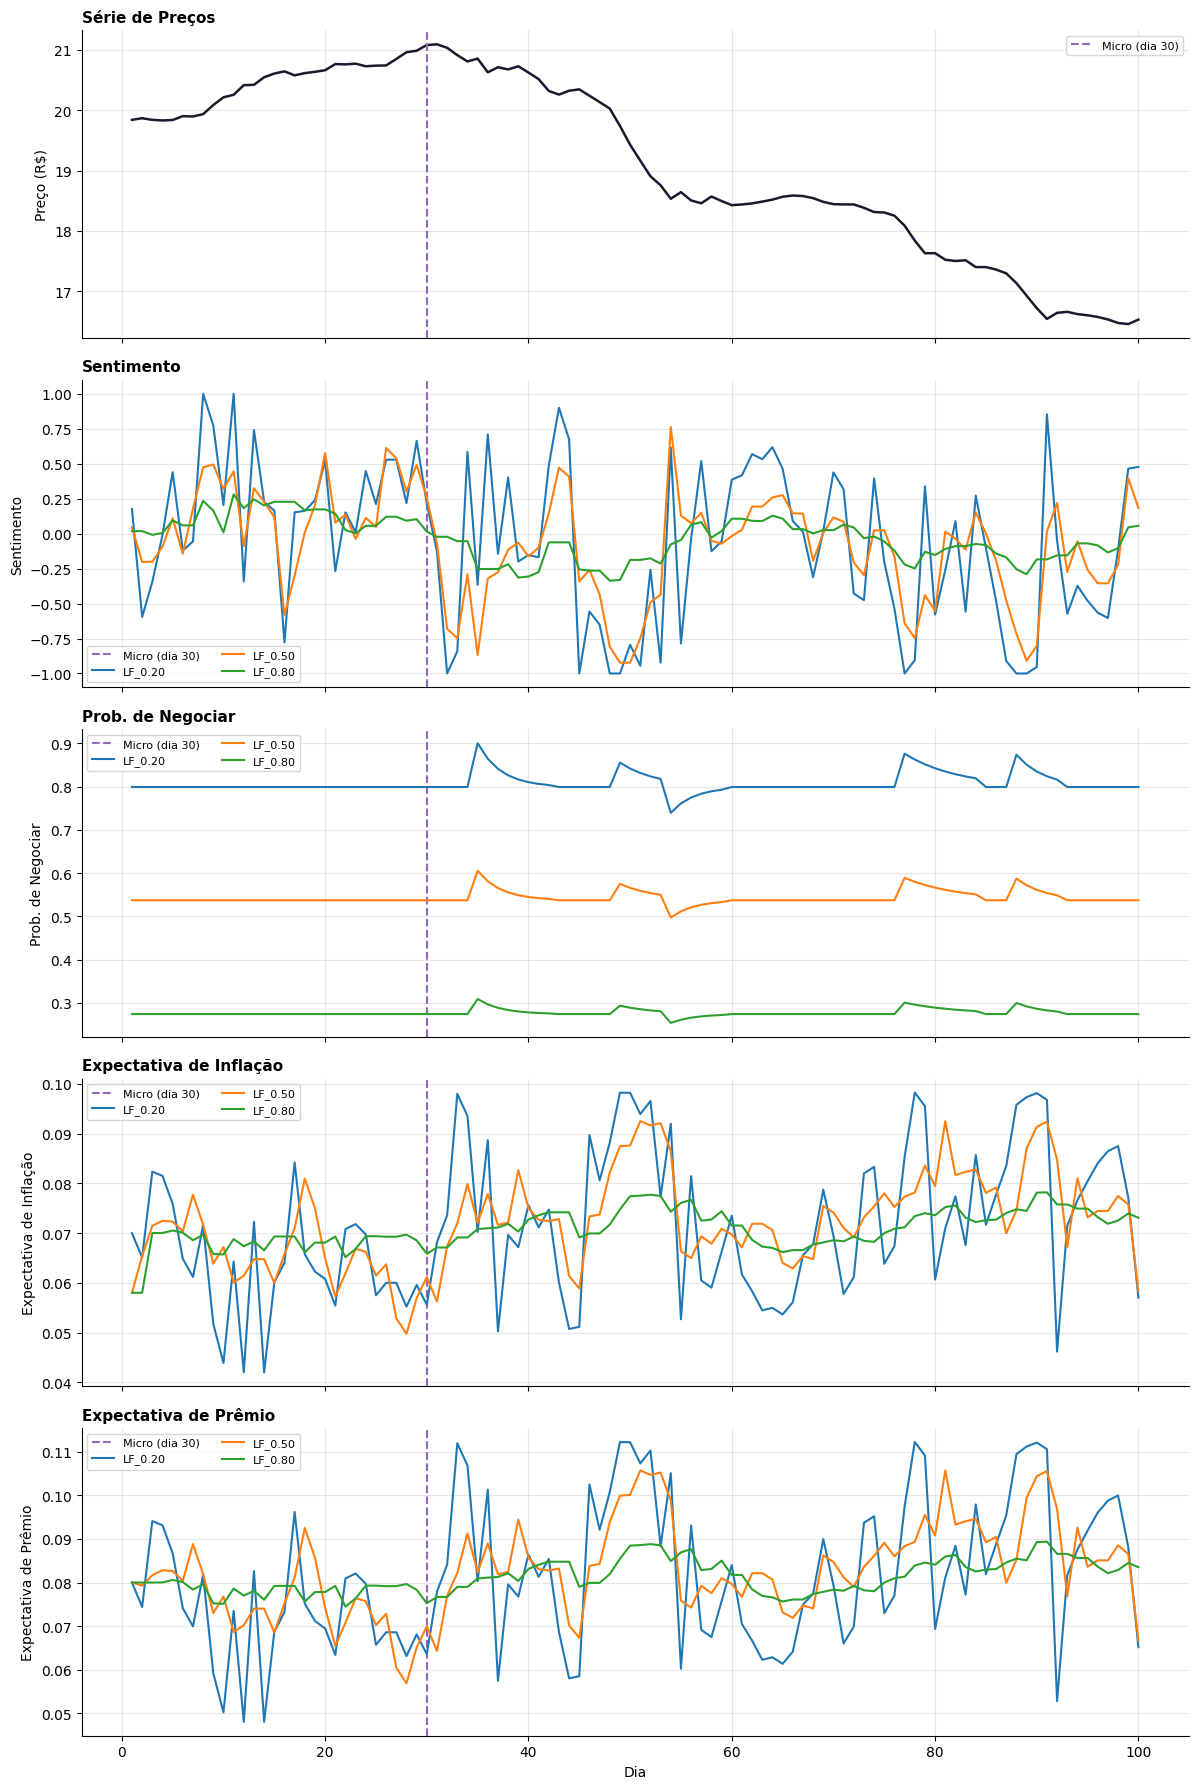

In [14]:
params = copy.deepcopy(SIM_PARAMS)
params["prob_choque_diario"] = 0.025  # sem choques aleatórios
params["choques"] = [
    {
        "categoria": "micro",
        "dia":       30,
        "vac":       50,   # vacância sobe 50%
        "custo":     30,   # custo de manutenção sobe 30%
    }
]

resultado = simular_experimento_choque_por_literacia(
    parametros_sistema=parametros_sistema,
    num_dias=100,
    sim_params=params,
    lf_targets=[0.2, 0.5, 0.8],
    agentes_por_grupo=5,
)